In [88]:
library(tidyverse)
library(ggplot2)
library(readr)
library(stringr)

In [16]:
celltype_metadata <- readr::read_csv(
  paste0(results_dir, "/celltype_metadata_final.csv")
)

Rows: 587448 Columns: 16
-- Column specification --------------------------------------------------------
Delimiter: ","
chr (9): cell_type, cell_category, patient_ID, exp_name, patient_exp, sample...
dbl (6): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_months
lgl (1): is_sample_primary

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [83]:
#get percentages of cell types per patient
celltype_percentage_patient = celltype_metadata %>%
  group_by(patient_ID, cell_category) %>%
  summarise(n = n()) %>%
  group_by(patient_ID) %>%
  mutate(percentage = n / sum(n) * 100)

`summarise()` has grouped output by 'patient_ID'. You can override using the
`.groups` argument.


In [19]:
cell_category_color <- c(
  "Actin+ cells" = "#AAAAFF",
  "B cells" = "#FFFF00",
  "DCs" = "#00FF00",
  "Endothelial cells" = "#55FFFF",
  "Granulocytes" = "#FF00FF",
  "Lymphatic endothelial cells" = "#0055FF",
  "Mast cells" = "#AA007F",
  "MDSCs" = "#00007F",
  "NFC" = "#A9A9A9",
  "NK cells" = "#00AAFF",
  "PCs" = "#FFFF7F",
  "CD4+ T cells" = "#0055FF",
  "CD8+ T cells" = "#FF0000",
  "Treg cells" = "#AAFF7F",
  "Tumor cells" = "#555555",
  "Epithelial cells" = "#FFCC99",
  "M1 macrophages" = "#00557F",
  "M2 macrophages" = "#00AA7F",
  "M1/M2 macrophages" = "#007F7F"
)

In [337]:
cell_category_color <- c(
  # Structural / unclear
  "NFC" = "#A9A9A9",
  "Tumor cells" = "#668300",

  # Structural
  "Actin+ cells" = "#4DD0E1",

  # Endothelial
  "Endothelial cells" = "#4DA3D9",
  "Lymphatic endothelial cells" = "#056FBF",

  # Myeloid lineage
  "DCs" = "#81C784",
  "Granulocytes" = "#C77CFF",
  "MDSCs" =  "#6A4C93",

  # Macrophages
  "M1 macrophages" = "#1F4E8C",
  "M2 macrophages" = "#00796B",
  "M1/M2 macrophages" = "#4DB6AC",

  # Mast
  "Mast cells" = "#AA007F",

  # Lymphoid lineage
  "NK cells" = "#00AAFF",

  # B lineage
  "B cells" = "#F9A825",
  "PCs" = "#FDD835",

  # T cells
  "CD4+ T cells" = "#3949AB",
  "CD8+ T cells" = "#C10100",
  "Treg cells" = "#9CCC65",

  # Epithelial
  "Epithelial cells" = "#FFCC99"
)


In [375]:
cell_category_color <- c(
  # Tumor and Unknown
  "NFC" = "lightgrey",
  "Tumor cells" = "#008856",
  "Epithelial cells" = "#8db600",

  # Structural
  "Actin+ cells" = "#C497D0",

  # Endothelial
  "Endothelial cells" = "#604e97",
  "Lymphatic endothelial cells" = "#875692",

  # Myeloid lineage
  "DCs" = "#a1caf1",
  "Granulocytes" = "#0067a5",
  "MDSCs" =  "#E31A1C",

  # Macrophages
  "M1 macrophages" = "#f99379",
  "M2 macrophages" = "#b3446c",
  "M1/M2 macrophages" = "#e68fac",

  # Mast
  "Mast cells" = "#654522",

  # NK
  "NK cells" = "#882d17",

  # B lineage
  "B cells" = "#dcd300",
  "PCs" = "#FFFF80",

  # T cells
  "CD4+ T cells" = "#f38400",
  "CD8+ T cells" = "#e25822",
  "Treg T cells" = "#f6a600"

)


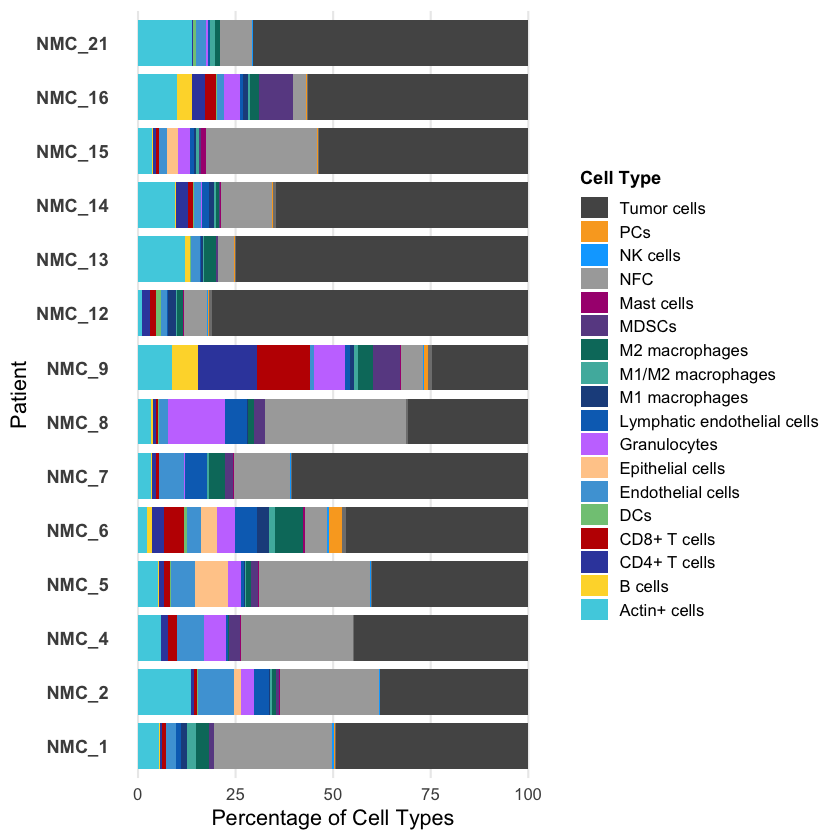

In [93]:
## 1. Patient order (explicit, stable)
## If patient_exp is like "P_1", "P_2", ...
celltype_percentage_patient$patient_id_num <-
  as.integer(str_extract(celltype_percentage_patient$patient_ID, "(?<=NMC_)\\d+"))
celltype_percentage_patient = celltype_percentage_patient %>%
arrange(patient_id_num)
#factor based on this order patient_exp
celltype_percentage_patient$patient_ID <-
  factor(
    celltype_percentage_patient$patient_ID,
    levels = unique(celltype_percentage_patient$patient_ID)
  )

## 2. Cell types: alphabetical BUT reversed for stacking
celltype_levels_alpha <- sort(unique(celltype_percentage_patient$cell_category))
celltype_levels_rev   <- rev(celltype_levels_alpha)

celltype_percentage_patient$cell_category <-
  factor(
    celltype_percentage_patient$cell_category,
    levels = celltype_levels_rev
  )

## Reorder colors accordingly
cell_category_color_rev <- cell_category_color[celltype_levels_rev]


In [527]:
patient_tissue <- celltype_metadata %>%
    select(patient_ID, sample_tissue) %>%
    unique()
patient_tissue

patient_ID,sample_tissue
<chr>,<chr>
NMC_1,Submandibular Gland
NMC_2,Lung
NMC_4,Thoracic Spine
NMC_5,Nasal Sinus
NMC_6,Lung
NMC_7,Cervical
NMC_8,Lung
NMC_9,Lung
NMC_12,Cervical


In [406]:
#calculate the total number of cells per patient
patient_cell_counts <- celltype_metadata %>%
  group_by(patient_ID) %>%
  summarise(total_cells = n()) %>%
#order like patient_tissue dataframe
  arrange(factor(patient_ID, levels = patient_tissue$patient_ID))
patient_cell_counts

patient_ID,total_cells
<chr>,<int>
NMC_1,23845
NMC_2,21948
NMC_4,24233
NMC_5,94583
NMC_6,38066
NMC_7,64784
NMC_8,24963
NMC_9,72232
NMC_12,27695


In [479]:
shared_margin <- margin(t = 5, r = 10, b = 5, l = 10)


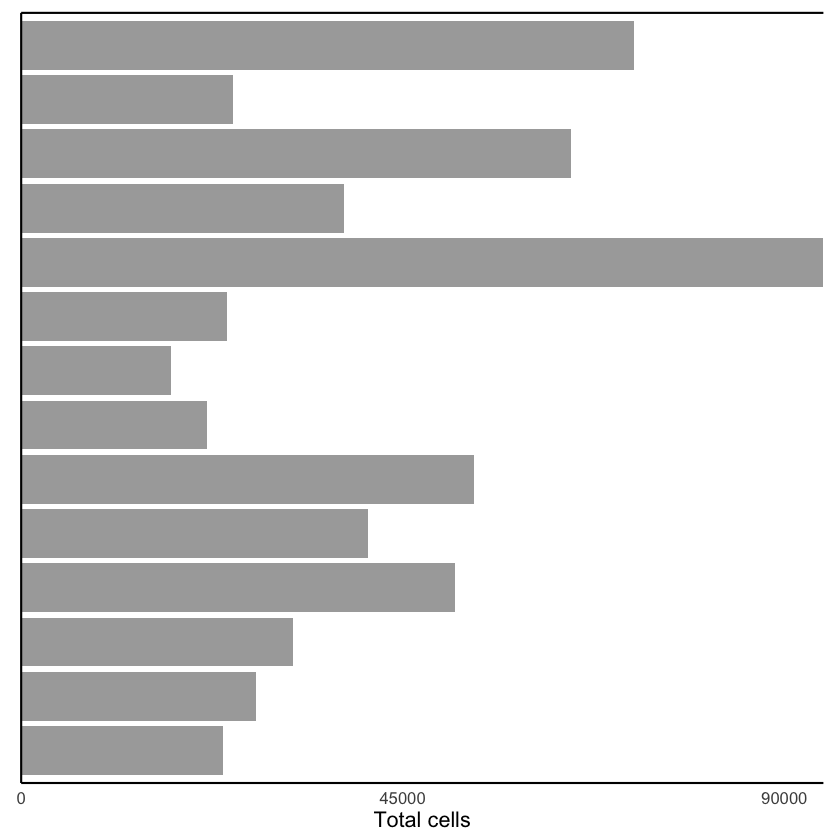

In [480]:
#barplot of total number of cells
anno_right <- ggplot(patient_cell_counts, aes(x = patient_ID, y = total_cells)) +
  geom_bar(stat = "identity", fill = "darkgrey") +
  theme_minimal() +
  theme(
    axis.title.y = element_blank(),
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
  ) +
  ylab("Total cells") +
  scale_y_continuous(expand = c(0, 0), breaks = c(0,45000, 90000), sec.axis = dup_axis()) +
  coord_flip() +
  theme(
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),
  panel.border = element_blank(),  # remove full box

  # X axis lines
  axis.line.x.bottom = element_line(colour = "black", linewidth = 0.6),
  axis.line.x.top    = element_line(colour = "black", linewidth = 0.6),

  # Y axis lines
  axis.line.y.left   = element_line(colour = "black", linewidth = 0.6),
  axis.line.y.right  = element_blank(),  # remove right side

  panel.grid = element_blank(),
  axis.text.x.top  = element_blank(),
  axis.ticks.x.top = element_blank(),
  axis.title.x.top = element_blank(),
  plot.margin = shared_margin)
anno_right 

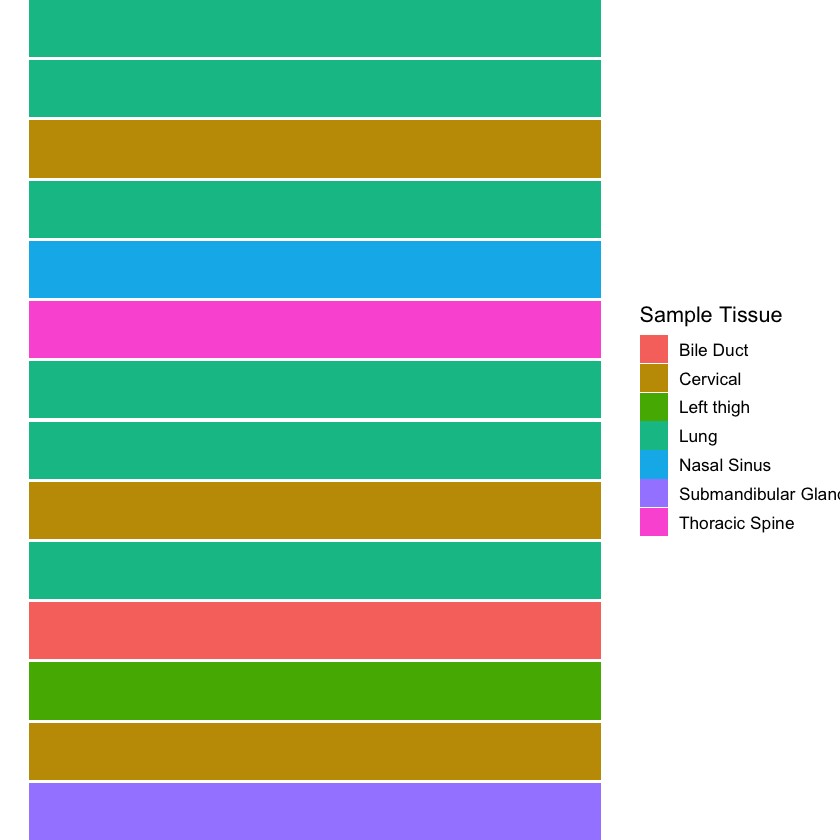

In [537]:
anno_top <- ggplot(
  patient_tissue,
  aes(
    x    = 1,        # 🔑 dummy DISCRETE axis
    y    = patient_ID,
    fill = sample_tissue,
  )
) +
  geom_tile(height = 0.95) +   # controls block thickness ONLY
  scale_y_discrete(expand = c(0, 0)) +   # 🔑 remove spacing
  labs(fill = "Sample Tissue") +
  theme_void(base_size = 13) +
  theme(
    plot.margin     = margin(0, 0, 0, 0),
    legend.position = "right"
  )
anno_top

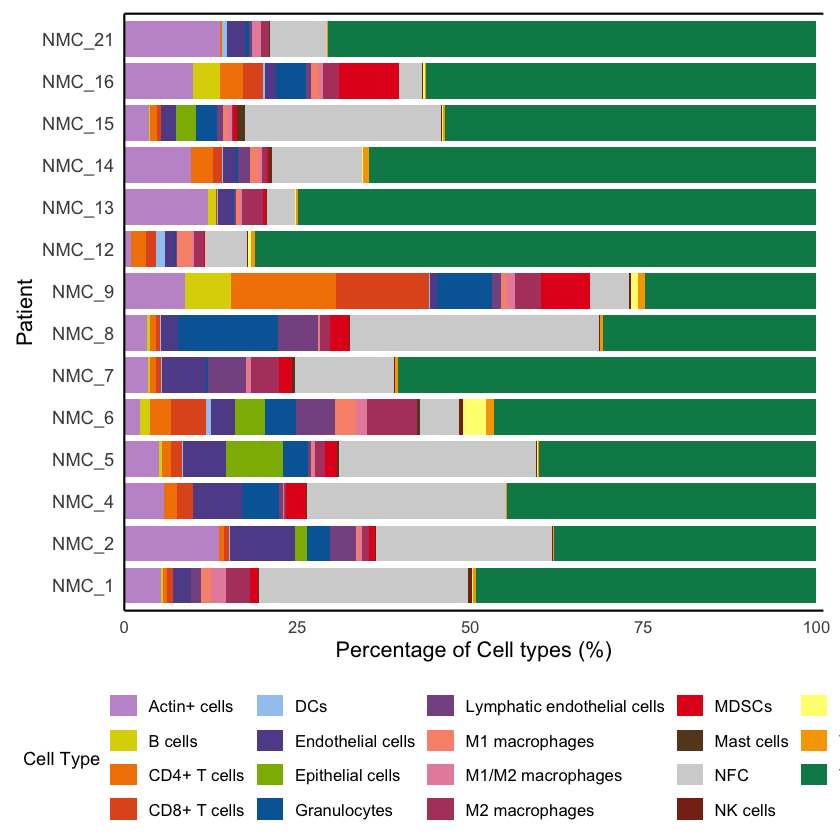

In [481]:
main_plot = ggplot(
  celltype_percentage_patient,
  aes(x = percentage, y = patient_ID, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  scale_fill_manual(values = cell_category_color) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Percentage of Cell types (%)",
    y = "Patient",
    fill = "Cell Type"
  ) +
  scale_x_continuous(limits = c(0, 101), expand = c(0, 0), sec.axis = dup_axis()) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),
    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "bottom",
    panel.border = element_blank(),
  axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
  axis.line.x.top    = element_line(colour="black", linewidth=0.6),
  axis.line.y.left   = element_line(colour="black", linewidth=0.6),
  axis.line.y.right  = element_blank(),
  axis.text.x.top  = element_blank(),
  axis.ticks.x.top = element_blank(),
  axis.title.x.top = element_blank(),
  panel.grid = element_blank(),
  plot.margin = shared_margin
  )
main_plot

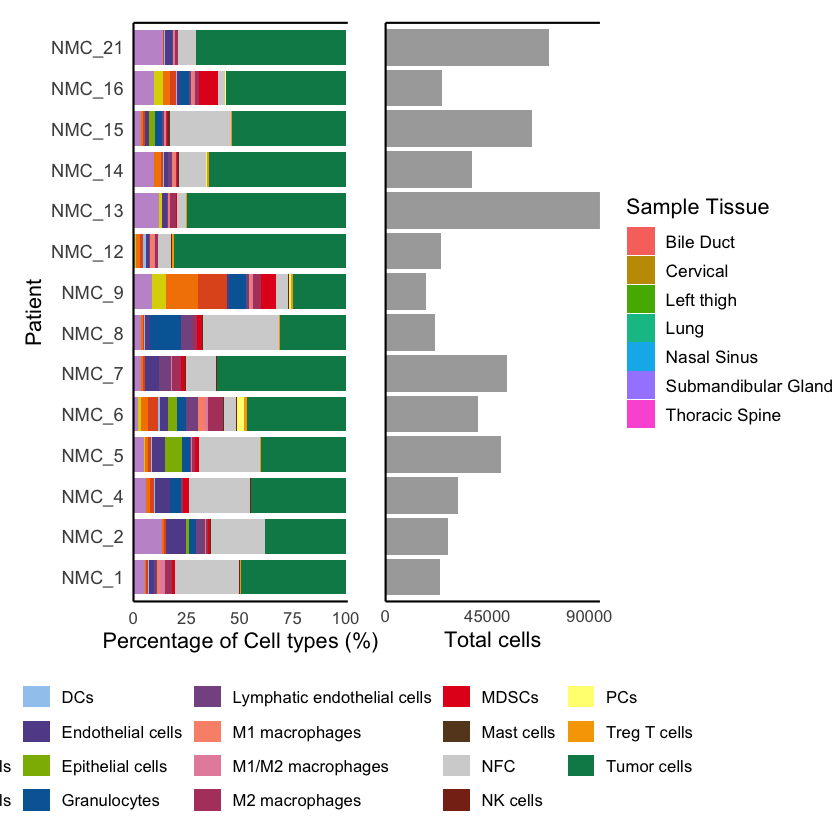

In [538]:
final_plot <-
  main_plot |
  anno_right |
  anno_top +
  plot_layout(
    widths = c(1,3,8)  # annotation thinner than bars
  )

final_plot

In [539]:
ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/celltype_percentages_patient_legend.pdf",
  plot = last_plot(),
  width = 18,   # wider
  height = 8,   # shorter
  units = "in"
)

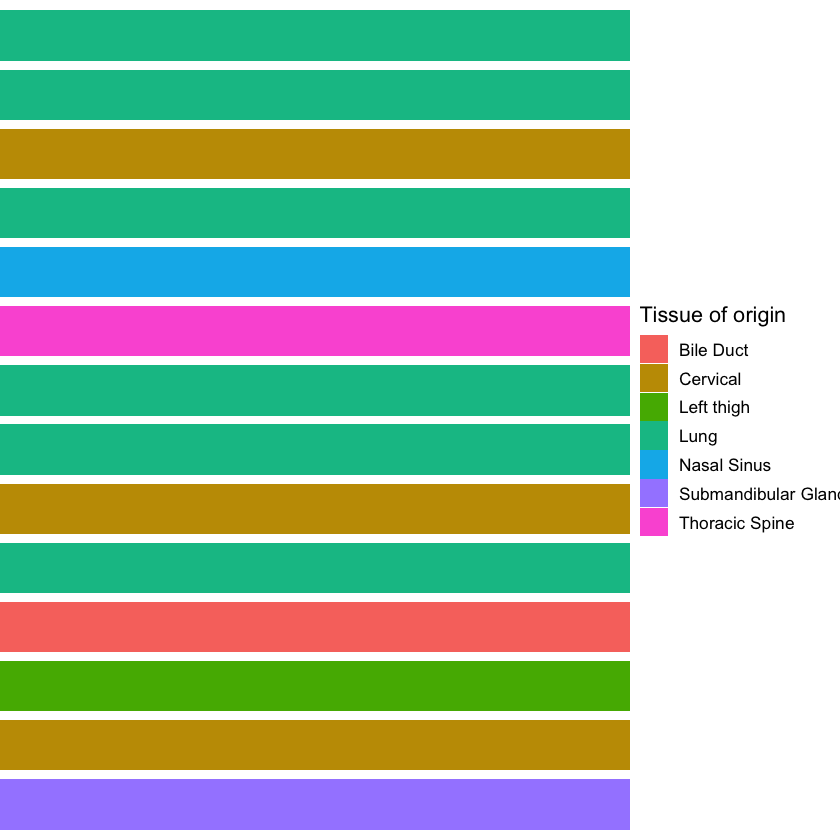

In [210]:
p_anno <- ggplot(
  patient_tissue,
  aes(
    y    = patient_ID,
    x    = 1,
    fill = sample_tissue
  )
) +
  geom_tile(width = 1, height = 0.85) +
  scale_x_continuous(expand = c(0, 0)) +
  labs(fill = "Tissue of origin") +
  theme_void(base_size = 13) +
  theme(
    legend.position = "right"
  )
p_anno

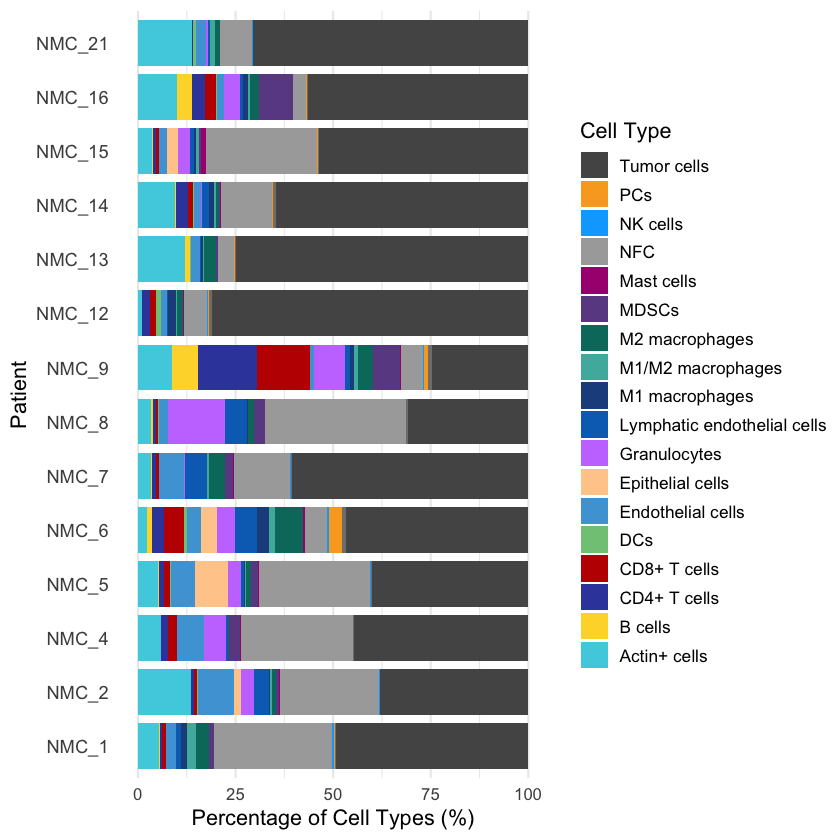

In [214]:

p_bar <- ggplot(
  celltype_percentage_patient,
  aes(
    y    = patient_ID,
    x    = percentage,
    fill = cell_category
  )
) +
  geom_col(width = 0.85) +
  scale_fill_manual(values = cell_category_color_rev) +
  labs(
    x    = "Percentage of Cell Types (%)",
    y    = "Patient",
    fill = "Cell Type"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    panel.grid.major.y = element_blank(),
    axis.text.y        = element_text(size = 11),
    axis.text.x        = element_text(size = 10),
    axis.title         = element_text(size = 13)
  )

  p_bar


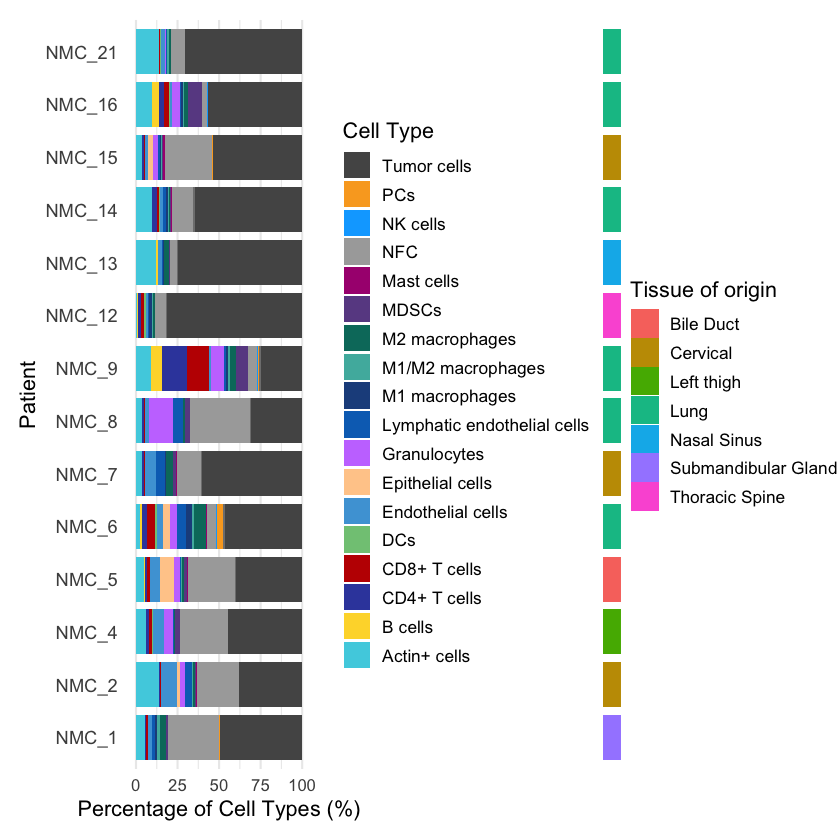

In [215]:
library(patchwork)

p_bar + p_anno +
  plot_layout(widths = c(6, 0.6))


In [142]:
ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/celltype_percentages_patient_nolegend.pdf",
  plot = last_plot(),
  width = 7,   # wider
  height = 5,   # shorter
  units = "in"
)


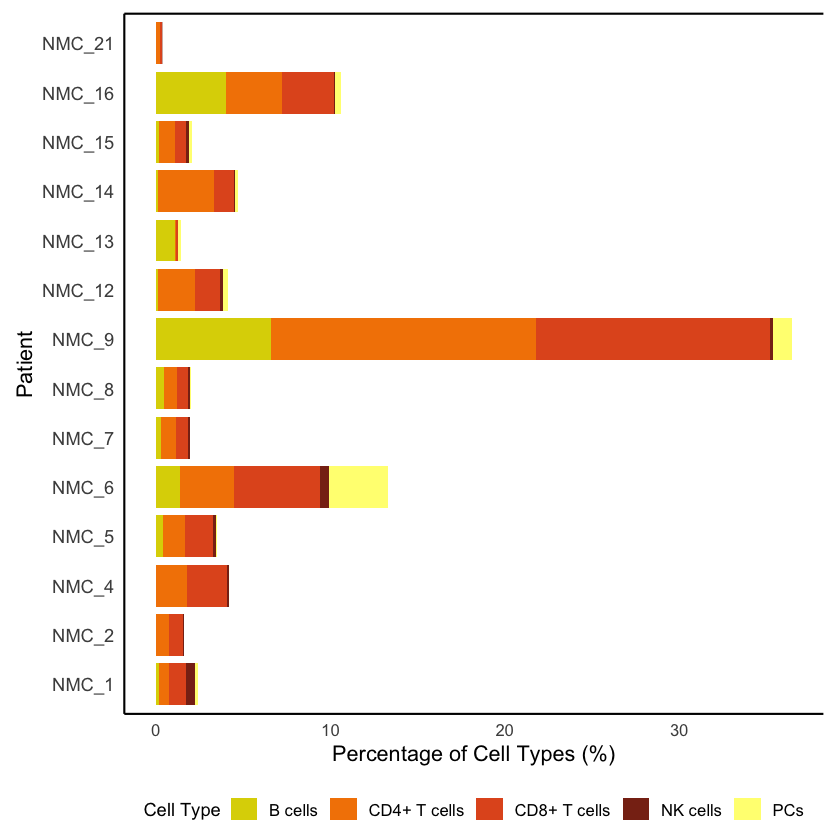

In [541]:
#only lymphoid cells plotting
lymphoid_cells <- c("B cells", "PCs", "CD4+ T cells", "CD8+ T cells", "Treg cells", "NK cells")
celltype_percentage_patient_lymphoid <- celltype_percentage_patient %>%
  filter(cell_category %in% lymphoid_cells)
ggplot(
  celltype_percentage_patient_lymphoid,
  aes(x = patient_ID, y = percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  coord_flip() +
  scale_fill_manual(values = cell_category_color) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Patient",
    y = "Percentage of Cell Types (%)",
    fill = "Cell Type"
  ) +
  theme_minimal(base_size = 13) +
  scale_y_continuous(sec.axis = dup_axis()) +
    theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),
    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "bottom",
    panel.border = element_blank(),
  axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
  axis.line.x.top    = element_line(colour="black", linewidth=0.6),
  axis.line.y.left   = element_line(colour="black", linewidth=0.6),
  axis.line.y.right  = element_blank(),
  axis.text.x.top  = element_blank(),
  axis.ticks.x.top = element_blank(),
  axis.title.x.top = element_blank(),
  panel.grid = element_blank(),
  plot.margin = shared_margin
  )


ggsave(filename = "/Users/jawadalaaedeen/Desktop/celltype_percentages_patient_lymphoid.pdf",
       plot = last_plot(),
       width = 7,   # wider
       height = 5,   # shorter
       units = "in"
)

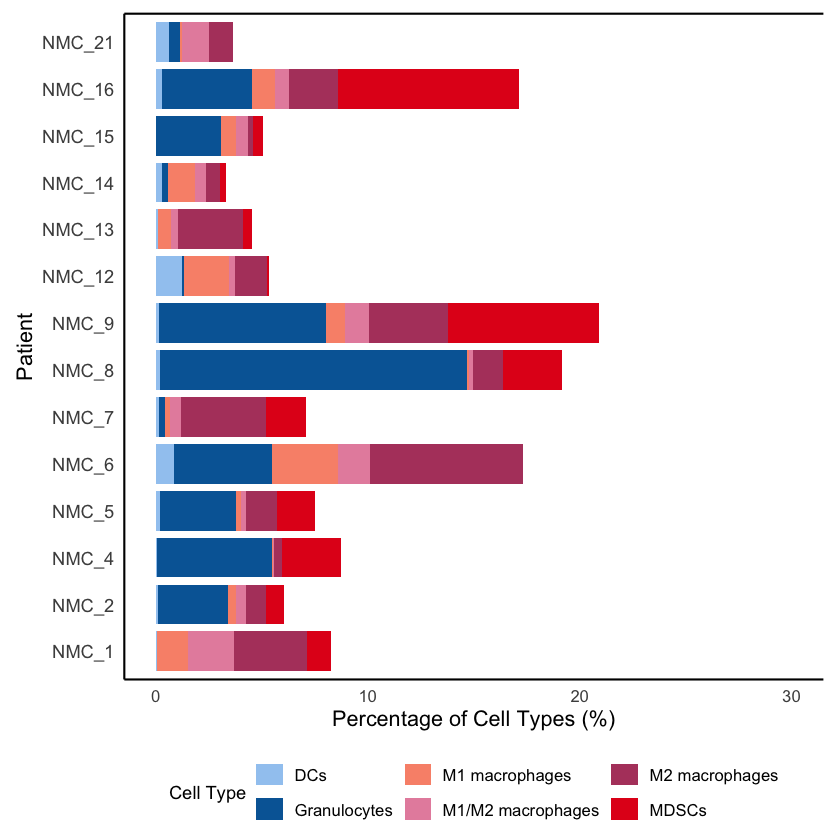

In [543]:
#same for myeloid cells
myeloid_cells <- c("DCs", "Granulocytes", "MDSCs", "M1 macrophages", "M2 macrophages", "M1/M2 macrophages")
celltype_percentage_patient_myeloid <- celltype_percentage_patient %>%
  filter(cell_category %in% myeloid_cells)
ggplot(
  celltype_percentage_patient_myeloid,
  aes(x = patient_ID, y = percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  coord_flip() +
  scale_y_continuous(
    limits = c(0, 30),
    breaks = c(0, 10, 20, 30),
    sec.axis = dup_axis()
  ) +
  scale_fill_manual(values = cell_category_color) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Patient",
    y = "Percentage of Cell Types (%)",
    fill = "Cell Type"
  ) +
  theme_minimal(base_size = 13) +
    theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),
    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "bottom",
    panel.border = element_blank(),
  axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
  axis.line.x.top    = element_line(colour="black", linewidth=0.6),
  axis.line.y.left   = element_line(colour="black", linewidth=0.6),
  axis.line.y.right  = element_blank(),
  axis.text.x.top  = element_blank(),
  axis.ticks.x.top = element_blank(),
  axis.title.x.top = element_blank(),
  panel.grid = element_blank(),
  plot.margin = shared_margin
  )
ggsave(filename = "/Users/jawadalaaedeen/Desktop/celltype_percentages_patient_myeloid.pdf",
       plot = last_plot(),
       width = 7,   # wider
       height = 5,   # shorter
       units = "in")

In [114]:
celltype_percentage_patient = celltype_percentage_patient %>%
mutate("cell_group" = 
case_when(
  cell_category %in% c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs") ~ "Lymphoid",
  cell_category %in% c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells") ~ "Myeloid",
  cell_category %in% c("Endothelial cells", "Lymphatic endothelial cells", "Actin+ cells") ~ "Stromal",
  cell_category %in% c("Epithelial cells", "Tumor cells") ~ "Tumor and Epithelial",
  cell_category == "NFC" ~ "Others"))

In [115]:
#calculate percentages per group per patient
celltype_percentage_patient_group = celltype_percentage_patient %>%
group_by(patient_ID, cell_group) %>%
summarise(n = sum(n)) %>%
group_by(patient_ID) %>%
mutate(percentage = n / sum(n) * 100)
celltype_percentage_patient_group

`summarise()` has grouped output by 'patient_ID'. You can override using the
`.groups` argument.


patient_ID,cell_group,n,percentage
<fct>,<chr>,<int>,<dbl>
NMC_1,Lymphoid,681,2.855945
NMC_1,Myeloid,1982,8.312015
NMC_1,Others,7223,30.291466
NMC_1,Stromal,2233,9.364647
NMC_1,Tumor and Epithelial,11726,49.175928
NMC_2,Lymphoid,388,1.767815
NMC_2,Myeloid,1378,6.278476
NMC_2,Others,5569,25.373610
NMC_2,Stromal,5890,26.836158


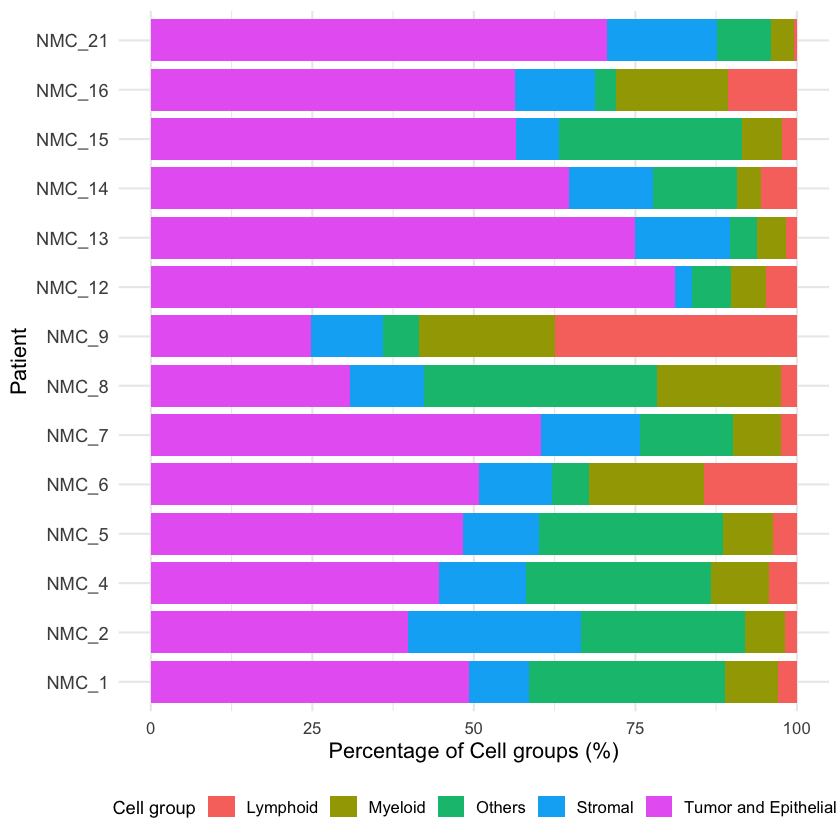

In [147]:
ggplot(
  celltype_percentage_patient_group,
  aes(x = patient_ID, y = percentage, fill = cell_group),
) +
  geom_bar(stat = "identity", width = 0.85) +
  coord_flip() +
  labs(
    x = "Patient",
    y = "Percentage of Cell groups (%)",
    fill = "Cell group"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),

    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "bottom"

  )

In [148]:
ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/cellgroup_percentage_patient_legend.pdf",
  plot = last_plot(),
  width = 7,   # wider
  height = 5,   # shorter
  units = "in"
)


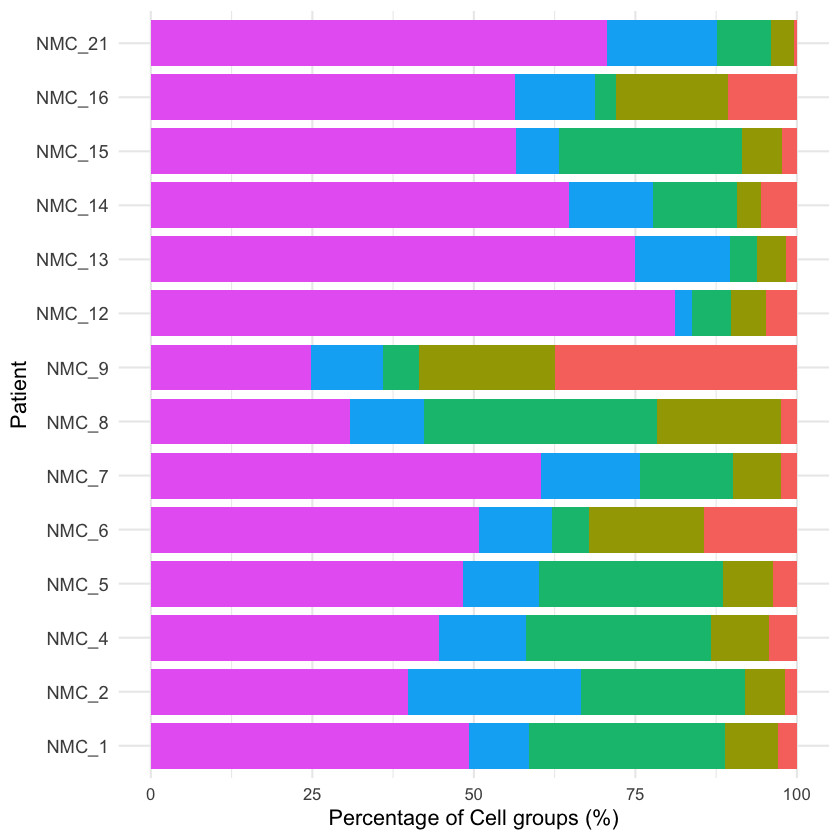

In [149]:
ggplot(
  celltype_percentage_patient_group,
  aes(x = patient_ID, y = percentage, fill = cell_group),
) +
  geom_bar(stat = "identity", width = 0.85) +
  coord_flip() +
  labs(
    x = "Patient",
    y = "Percentage of Cell groups (%)",
    fill = "Cell group"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),

    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none"

  )

In [150]:
ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/cellgroup_percentage_patient_nolegend.pdf",
  plot = last_plot(),
  width = 7,   # wider
  height = 5,   # shorter
  units = "in"
)


In [163]:
#next up would be to compare the cell types across the sample tissue
#get percentages of cell types per patient
celltype_percentage_tissue = celltype_metadata %>%
  group_by(sample_tissue, cell_category) %>%
  summarise(n = n()) %>%
  group_by(sample_tissue) %>%
  mutate(percentage = n / sum(n) * 100) %>%
  arrange(sample_tissue)

`summarise()` has grouped output by 'sample_tissue'. You can override using the
`.groups` argument.


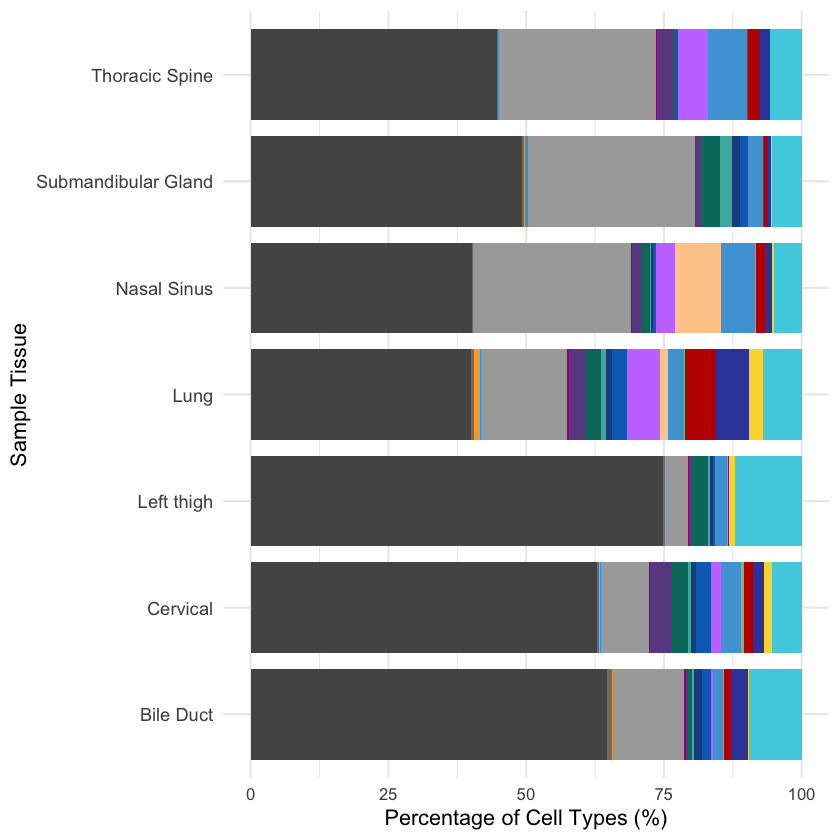

In [178]:
ggplot(
  celltype_percentage_tissue,
  aes(x = sample_tissue, y = percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  coord_flip() +
  scale_fill_manual(values = cell_category_color_rev) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Sample Tissue",
    y = "Percentage of Cell Types (%)",
    fill = "Cell Type"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),

    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none"

  )
ggsave(
    filename = "/Users/jawadalaaedeen/Desktop/celltype_percentages_tissue.pdf",
    plot = last_plot(),
    width = 7,   # wider
    height = 5,   # shorter
    units = "in"
  )

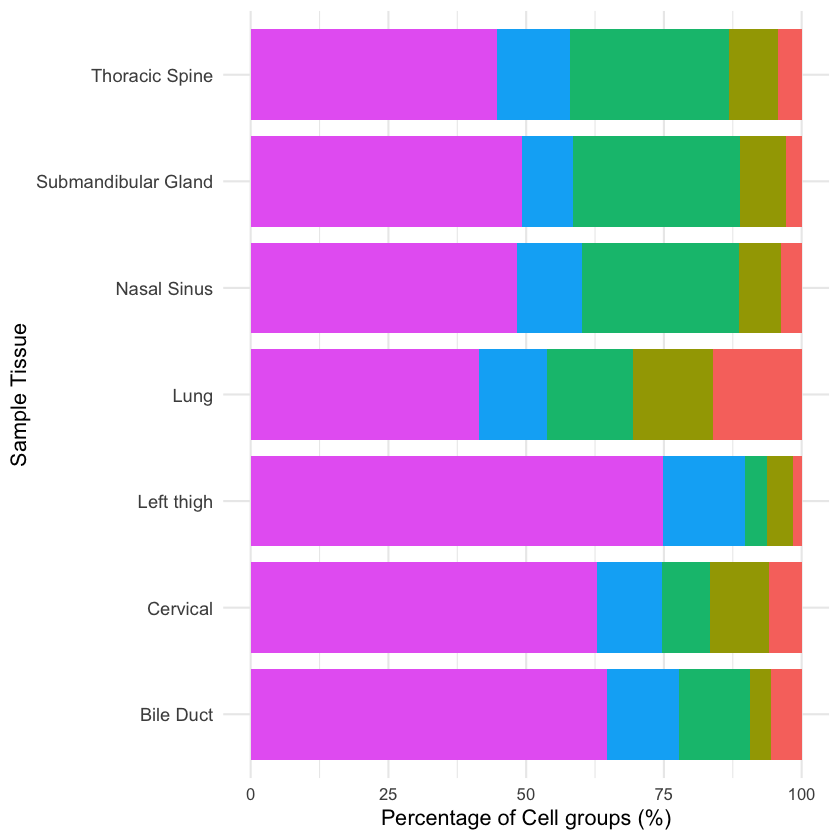

In [ ]:
celltype_percentage_tissue = celltype_percentage_tissue %>%
mutate("cell_group" = 
case_when(
  cell_category %in% c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs") ~ "Lymphoid",
  cell_category %in% c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells") ~ "Myeloid",
  cell_category %in% c("Endothelial cells", "Lymphatic endothelial cells", "Actin+ cells") ~ "Stromal",
  cell_category %in% c("Epithelial cells", "Tumor cells") ~ "Tumor and Epithelial",
  cell_category == "NFC" ~ "Others"))

#calculate percentages per group per patient
celltype_percentage_tissue_group = celltype_percentage_tissue %>%
group_by(sample_tissue, cell_group) %>%
summarise(n = sum(n)) %>%
group_by(sample_tissue) %>%
mutate(percentage = n / sum(n) * 100)
celltype_percentage_tissue_group

ggplot(
  celltype_percentage_tissue_group,
  aes(x = sample_tissue, y = percentage, fill = cell_group),
) +
  geom_bar(stat = "identity", width = 0.85) +
  coord_flip() +
  labs(
    x = "Sample Tissue",
    y = "Percentage of Cell groups (%)",
    fill = "Cell group"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),

    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none"

  )
ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/cellgroup_percentage_tissue.pdf",
  plot = last_plot(),
  width = 7,   # wider
  height = 5,   # shorter
  units = "in"
)

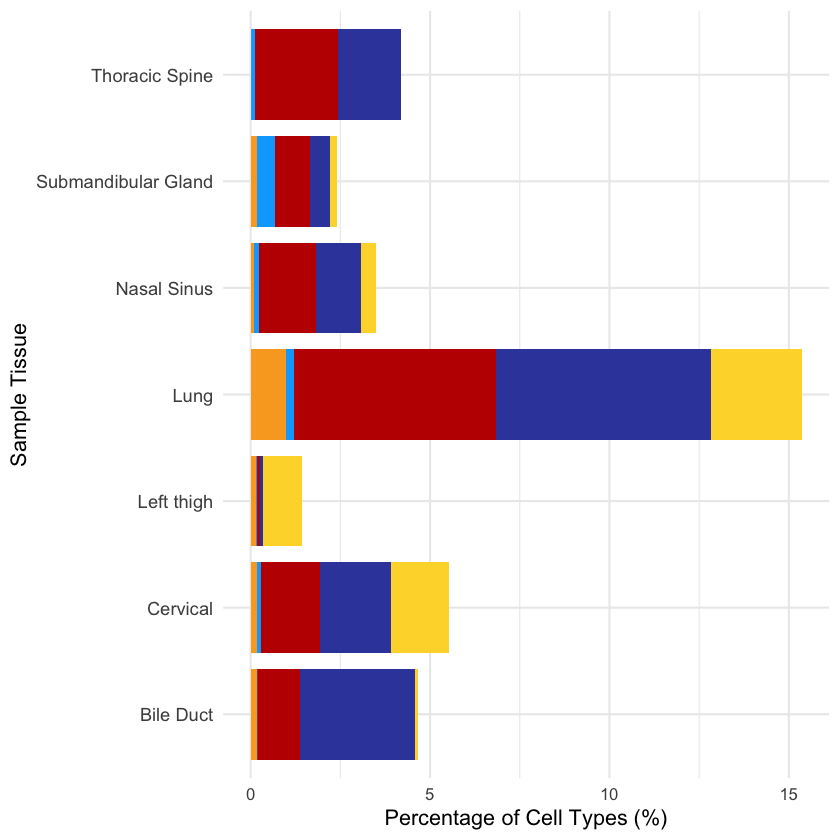

In [180]:
#only lymphoid cells plotting
lymphoid_cells <- c("B cells", "PCs", "CD4+ T cells", "CD8+ T cells", "Treg cells", "NK cells")
celltype_percentage_tissue_lymphoid <- celltype_percentage_tissue %>%
  filter(cell_category %in% lymphoid_cells)
ggplot(
  celltype_percentage_tissue_lymphoid,
  aes(x = sample_tissue, y = percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  coord_flip() +
  scale_fill_manual(values = cell_category_color_rev) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Sample Tissue",
    y = "Percentage of Cell Types (%)",
    fill = "Cell Type"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),
    #take out legend
    legend.position = "none"
  )

ggsave(filename = "/Users/jawadalaaedeen/Desktop/celltype_percentages_tissue_lymphoid.pdf",
       plot = last_plot(),
       width = 7,   # wider
       height = 5,   # shorter
       units = "in"
)

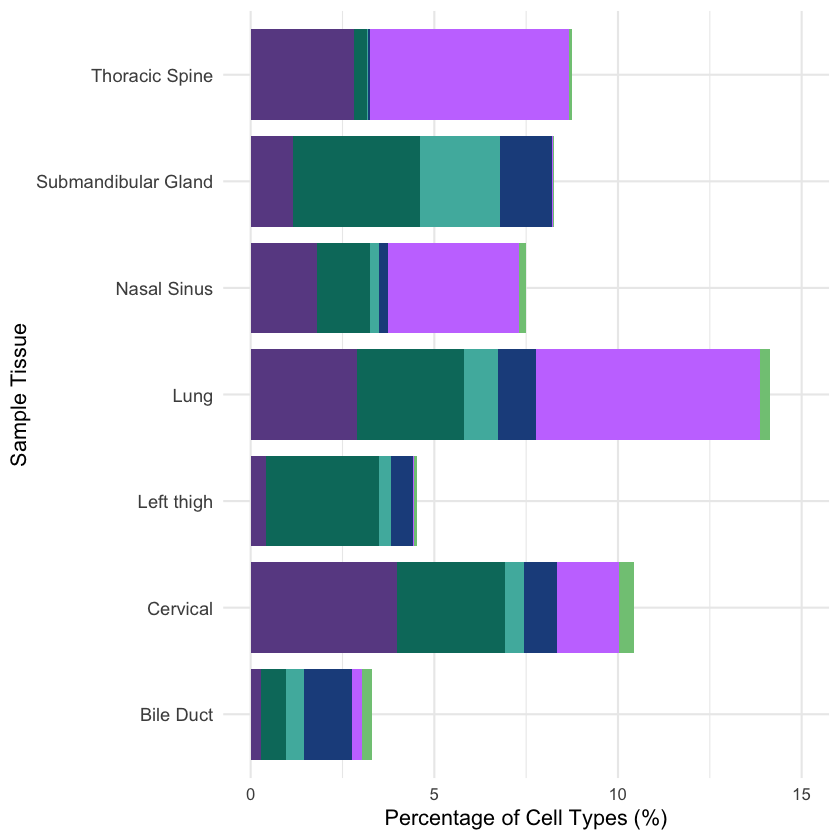

In [183]:
#same for myeloid cells
myeloid_cells <- c("DCs", "Granulocytes", "MDSCs", "M1 macrophages", "M2 macrophages", "M1/M2 macrophages")
celltype_percentage_tissue_myeloid <- celltype_percentage_tissue %>%
  filter(cell_category %in% myeloid_cells)
ggplot(
  celltype_percentage_tissue_myeloid,
  aes(x = sample_tissue, y = percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  coord_flip() +
  scale_y_continuous(
    limits = c(0, 15),
    breaks = c(0, 5, 10, 15)
  ) +
  scale_fill_manual(values = cell_category_color_rev) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Sample Tissue",
    y = "Percentage of Cell Types (%)",
    fill = "Cell Type"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),
    #take out legend
    legend.position = "none"
  )
ggsave(filename = "/Users/jawadalaaedeen/Desktop/celltype_percentages_patient_myeloid.pdf",
       plot = last_plot(),
       width = 7,   # wider
       height = 5,   # shorter
       units = "in")

In [169]:
#next up would be to compare the cell types across the sample tissue
#get percentages of cell types per patient
celltype_percentage_site = celltype_metadata %>%
  group_by(tumor_site, cell_category) %>%
  summarise(n = n()) %>%
  group_by(tumor_site) %>%
  mutate(percentage = n / sum(n) * 100) %>%
  arrange(tumor_site)

`summarise()` has grouped output by 'tumor_site'. You can override using the
`.groups` argument.


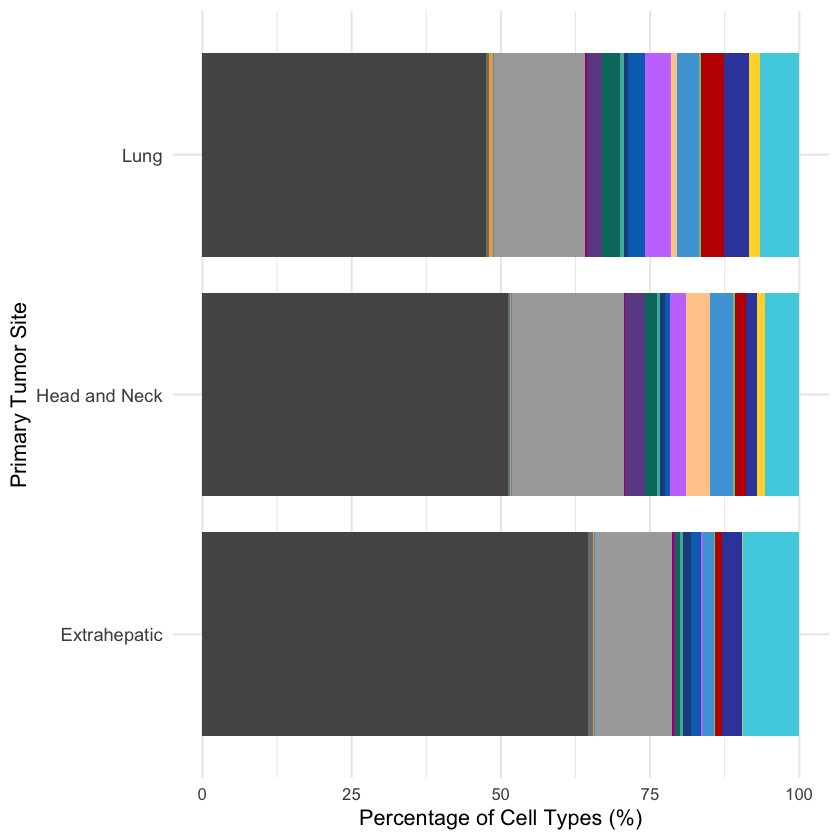

In [187]:
ggplot(
  celltype_percentage_site,
  aes(x = tumor_site, y = percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  coord_flip() +
  scale_fill_manual(values = cell_category_color_rev) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Primary Tumor Site",
    y = "Percentage of Cell Types (%)",
    fill = "Cell Type"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),

    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none"

  )

ggsave(
    filename = "/Users/jawadalaaedeen/Desktop/celltype_percentages_site.pdf",
    plot = last_plot(),
    width = 7,   # wider
    height = 5,   # shorter
    units = "in"
  )

`summarise()` has grouped output by 'tumor_site'. You can override using the
`.groups` argument.


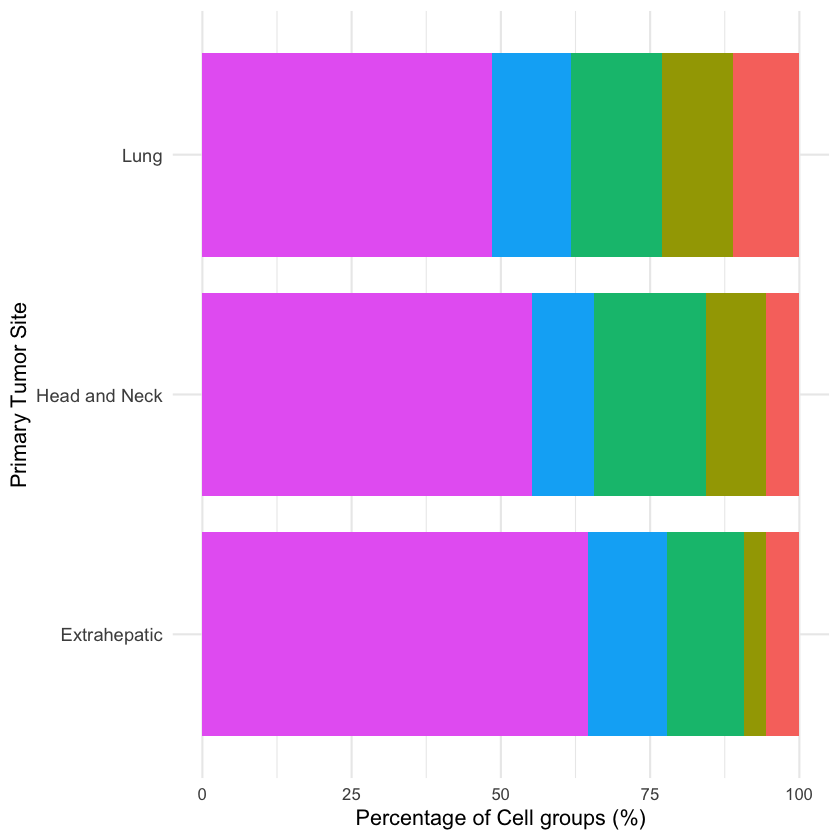

In [184]:
celltype_percentage_site = celltype_percentage_site %>%
mutate("cell_group" = 
case_when(
  cell_category %in% c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs") ~ "Lymphoid",
  cell_category %in% c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells") ~ "Myeloid",
  cell_category %in% c("Endothelial cells", "Lymphatic endothelial cells", "Actin+ cells") ~ "Stromal",
  cell_category %in% c("Epithelial cells", "Tumor cells") ~ "Tumor and Epithelial",
  cell_category == "NFC" ~ "Others"))

#calculate percentages per group per patient
celltype_percentage_site_group = celltype_percentage_site %>%
group_by(tumor_site, cell_group) %>%
summarise(n = sum(n)) %>%
group_by(tumor_site) %>%
mutate(percentage = n / sum(n) * 100)

ggplot(
  celltype_percentage_site_group,
  aes(x = tumor_site, y = percentage, fill = cell_group),
) +
  geom_bar(stat = "identity", width = 0.85) +
  coord_flip() +
  labs(
    x = "Primary Tumor Site",
    y = "Percentage of Cell groups (%)",
    fill = "Cell group"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),

    legend.text  = element_text(size = 10),
    legend.title = element_text(size = 11),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none"

  )
ggsave(
  filename = "/Users/jawadalaaedeen/Desktop/cellgroup_percentage_site.pdf",
  plot = last_plot(),
  width = 7,   # wider
  height = 5,   # shorter
  units = "in"
)

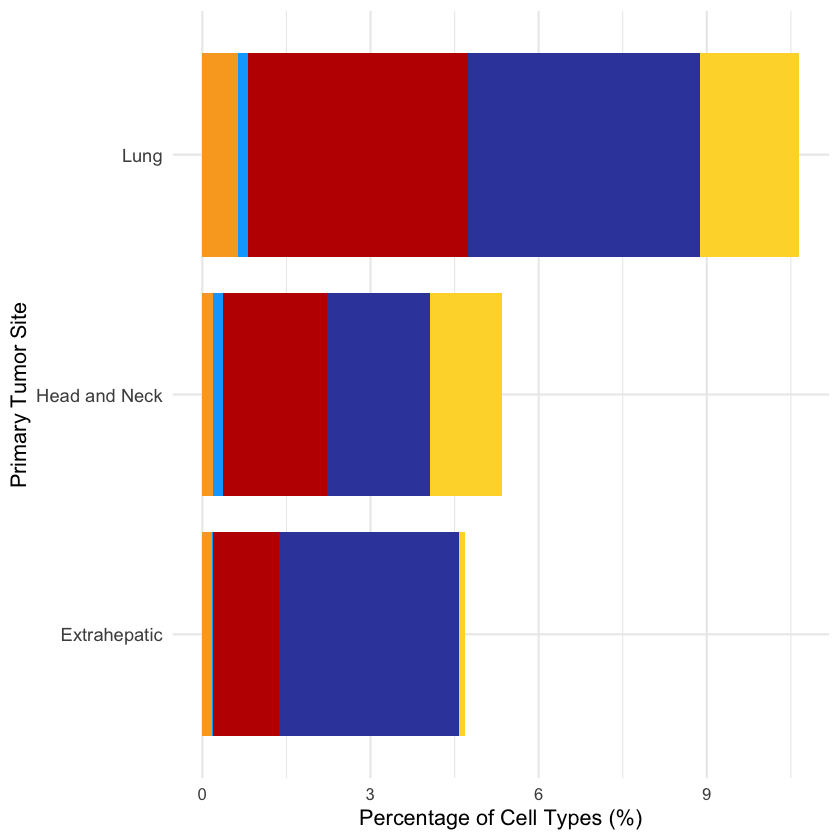

In [185]:
#only lymphoid cells plotting
lymphoid_cells <- c("B cells", "PCs", "CD4+ T cells", "CD8+ T cells", "Treg cells", "NK cells")
celltype_percentage_site_lymphoid <- celltype_percentage_site %>%
  filter(cell_category %in% lymphoid_cells)
ggplot(
  celltype_percentage_site_lymphoid,
  aes(x = tumor_site, y = percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  coord_flip() +
  scale_fill_manual(values = cell_category_color_rev) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Primary Tumor Site",
    y = "Percentage of Cell Types (%)",
    fill = "Cell Type"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),
    #take out legend
    legend.position = "none"
  )

ggsave(filename = "/Users/jawadalaaedeen/Desktop/celltype_percentages_site_lymphoid.pdf",
       plot = last_plot(),
       width = 7,   # wider
       height = 5,   # shorter
       units = "in"
)

Warning message:
"Removed 4 rows containing missing values or values outside the scale range
(`geom_bar()`)."
Warning message:
"Removed 4 rows containing missing values or values outside the scale range
(`geom_bar()`)."


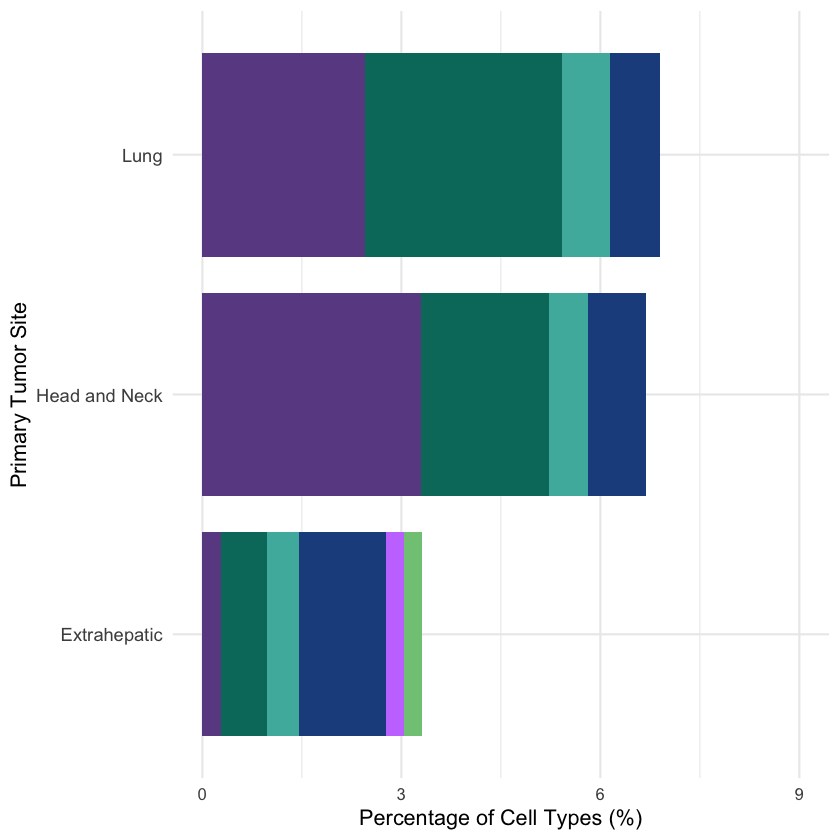

In [186]:
#same for myeloid cells
myeloid_cells <- c("DCs", "Granulocytes", "MDSCs", "M1 macrophages", "M2 macrophages", "M1/M2 macrophages")
celltype_percentage_site_myeloid <- celltype_percentage_site %>%
  filter(cell_category %in% myeloid_cells)
ggplot(
  celltype_percentage_site_myeloid,
  aes(x = tumor_site, y = percentage, fill = cell_category)
) +
  geom_bar(stat = "identity", width = 0.85) +
  coord_flip() +
  scale_y_continuous(
    limits = c(0, 9),
    breaks = c(0, 3, 6, 9)
  ) +
  scale_fill_manual(values = cell_category_color_rev) +
  guides(fill = guide_legend(reverse = TRUE)) +
  labs(
    x = "Primary Tumor Site",
    y = "Percentage of Cell Types (%)",
    fill = "Cell Type"
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y = element_text(size = 11),
    axis.text.x = element_text(size = 10),
    axis.title  = element_text(size = 13),
    #take out legend
    legend.position = "none"
  )
ggsave(filename = "/Users/jawadalaaedeen/Desktop/celltype_percentages_site_myeloid.pdf",
       plot = last_plot(),
       width = 7,   # wider
       height = 5,   # shorter
       units = "in")

In [ ]:
#Gates for the tumor markers...
tumor_markers_gates 